In [25]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r"C:\Users\Access\Desktop\Meth_Pr\data\Sleep_Work_Productivity_Surve2026-04-24_13_03_21.xlsx")

# clean age column

df['Enter your age ?']= df['Enter your age ?'].fillna(df['Enter your age ?'].median())

# rename the columns

df.rename(columns={
    'How would you rate your overall work productivity?': 'work_productivity',
    'How much do you think your sleep affects your productivity at work?': 'sleep_productivity_effect',
    'What factors do you believe impact your sleep quality? (Select all that apply)': 'sleep_factors',
    'How many breaks do you take during your workday when you are tired ?': 'break_nums',
    'How would you describe your energy levels throughout the workday?': 'energy_levels_per_workday',
    'What is your primary work environment?': 'primary_work_environment',
    'what is you gender ?': 'gender',
    'On a typical work night, how many hours of sleep do you get?': 'sleep_hours',
    
    'I wake up feeling refreshed and ready for work.':
        'wake_up_refreshed',

    'I have difficulty falling asleep the night before an important workday.':
        'difficulty_falling_asleep',

    'Enter your age ?':
        'age',

    'I wake up multiple times during the night and struggle to go back to sleep.':
        'wake_up_multiple_times',

    'On weekends or days off, my sleep schedule is very different from my workday schedule (e.g., sleeping in more than 2 hours later).':
        'weekend_sleep_schedule_difference',

    'I use electronic devices (phone, laptop, TV) in bed within 30 minutes of trying to sleep.':
        'device_use_before_sleep',

    'I find it hard to concentrate on work tasks for more than 15–20 minutes at a time.':
        'difficulty_concentrating',

    'I make careless mistakes (e.g., typos, miscalculations, forgetting steps) that I would not have made if better rested.':
        'careless_mistakes',

    'I often have to re-read emails, documents, or instructions because I lost focus.':
        'reread_due_to_focus_loss',

    'Learning a new software, process, or skill at work feels unusually difficult for me.':
        'difficulty_learning_new_skills',

    'I struggle to generate new ideas or creative solutions to problems.':
        'difficulty_generating_ideas',

    'I forget important tasks, deadlines, or details from meetings.':
        'forget_tasks_deadlines',

    'I feel irritable or short-tempered with colleagues or clients.':
        'irritable_with_colleagues',

    'Small setbacks or minor criticism feel overwhelming or upsetting.':
        'small_setbacks_overwhelming',

    'I avoid collaboration or group work because I feel mentally exhausted.':
        'avoid_collaboration',

    'I have difficulty controlling my emotions during stressful work situations (e.g., tight deadlines, difficult customers).':
        'difficulty_controlling_emotions',

    'I feel physically tired, sluggish, or heavy-eyed during work, even without heavy physical exertion.':
        'physically_tired_at_work',

    'In my job, I have had a close call, minor accident, or injury that I attribute to being too tired. If your job is sedentary, answer based on accidents like tripping, bumping into things, or spilling hot liquids.':
        'accident_due_to_tiredness',

    'Compared to when I am well-rested, I estimate my current work output is...':
        'current_work_output',

    'In the past month, how many work days did you feel you were “present but not productive” (getting less than half of your normal output) due to poor sleep?':
        'unproductive_workdays_due_to_sleep'

}, inplace=True)


df = df.replace(r'\n', ', ', regex=True)
df["sleep_factors"] = df["sleep_factors"].str.split(", ")

# index

df['sleep_quality_and_hygiene_index_(SQLI)']=(df['wake_up_refreshed']+df['difficulty_falling_asleep']+df['wake_up_multiple_times']+df['weekend_sleep_schedule_difference']+df['device_use_before_sleep'])*100/25
df['Cognitive_at_task_perforamnce_index_(CTPI)']=(((df['difficulty_concentrating']+df['careless_mistakes']+df['reread_due_to_focus_loss']+df['difficulty_learning_new_skills']+df['difficulty_generating_ideas']+df['forget_tasks_deadlines'])*100/30).round(2))
df['Emotional_and_social_impact_index(ESII)']=((df['irritable_with_colleagues']+df['small_setbacks_overwhelming']+df['avoid_collaboration']+df['difficulty_controlling_emotions'])*100/20)
df['Physical_and_safety_risk_index(PSRI)']=((df['physically_tired_at_work']+df['accident_due_to_tiredness'])*100/10)
df['Presentative_index(PI)']=(((df['unproductive_workdays_due_to_sleep'])*100/50).round(2))
df['Overall_sleep_Productivity_Impact_index(SPI)']=((df['Cognitive_at_task_perforamnce_index_(CTPI)']+df['Emotional_and_social_impact_index(ESII)']+df['Physical_and_safety_risk_index(PSRI)']+df['Presentative_index(PI)'])*0.2927)

In [26]:
df

,Submission Date,work_productivity,sleep_productivity_effect,sleep_factors,break_nums,energy_levels_per_workday,primary_work_environment,gender,sleep_hours,wake_up_refreshed,...,physically_tired_at_work,accident_due_to_tiredness,current_work_output,unproductive_workdays_due_to_sleep,sleep_quality_and_hygiene_index_(SQLI),Cognitive_at_task_perforamnce_index_(CTPI),Emotional_and_social_impact_index(ESII),Physical_and_safety_risk_index(PSRI),Presentative_index(PI),Overall_sleep_Productivity_Impact_index(SPI)
0,"Apr 24, 2026",High,Moderately,"[Stress, Screen time before bed]",3-4,High,Hybrid,Male,5–6 hrs,2,...,3,1,20–40% less,10,64.0,60.00,70.0,40.0,20.0,55.613000
1,"Apr 24, 2026",Moderate,Moderately,[Screen time before bed],3-4,Moderate,Hybrid,Female,6–7 hrs,3,...,3,3,60–80% less,13,60.0,60.00,60.0,60.0,26.0,60.296200
2,"Apr 24, 2026",Very high,Extremely,"[Stress, Exercise]",1-2,High,Office,Female,More than 8 hrs,5,...,3,2,60–80% less,7,64.0,60.00,35.0,50.0,14.0,46.539300
3,"Apr 24, 2026",High,Extremely,"[Stress, Screen time before bed]",3-4,Moderate,Hybrid,Female,6–7 hrs,2,...,3,3,20–40% less,20,88.0,60.00,40.0,60.0,40.0,58.540000
4,"Apr 24, 2026",Moderate,Extremely,"[Stress, Exercise, Screen time before bed, Roo...",1-2,Moderate,Remote,Male,7–8 hrs,3,...,3,3,80–100% less,23,84.0,73.33,50.0,60.0,46.0,67.124891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,"Apr 24, 2026",Moderate,Moderately,[Screen time before bed],1-2,Moderate,Hybrid,Male,6–7 hrs,3,...,3,2,60–80% less,2,80.0,40.00,55.0,50.0,4.0,43.612300
123,"Apr 24, 2026",Moderate,Moderately,[Screen time before bed],5 or more,Low,Office,Female,More than 8 hrs,2,...,5,3,80–100% less,18,72.0,76.67,45.0,80.0,36.0,69.566009
124,"Apr 24, 2026",Moderate,Extremely,[Stress],1-2,Moderate,Remote,Female,Less than 5 hrs,2,...,5,2,40–60% less,7,80.0,60.00,65.0,70.0,14.0,61.174300
125,"Apr 24, 2026",High,Significantly,"[Stress, Screen time before bed, Health issues]",3-4,Moderate,Remote,Female,5–6 hrs,2,...,4,2,40–60% less,12,68.0,56.67,100.0,60.0,24.0,70.444109


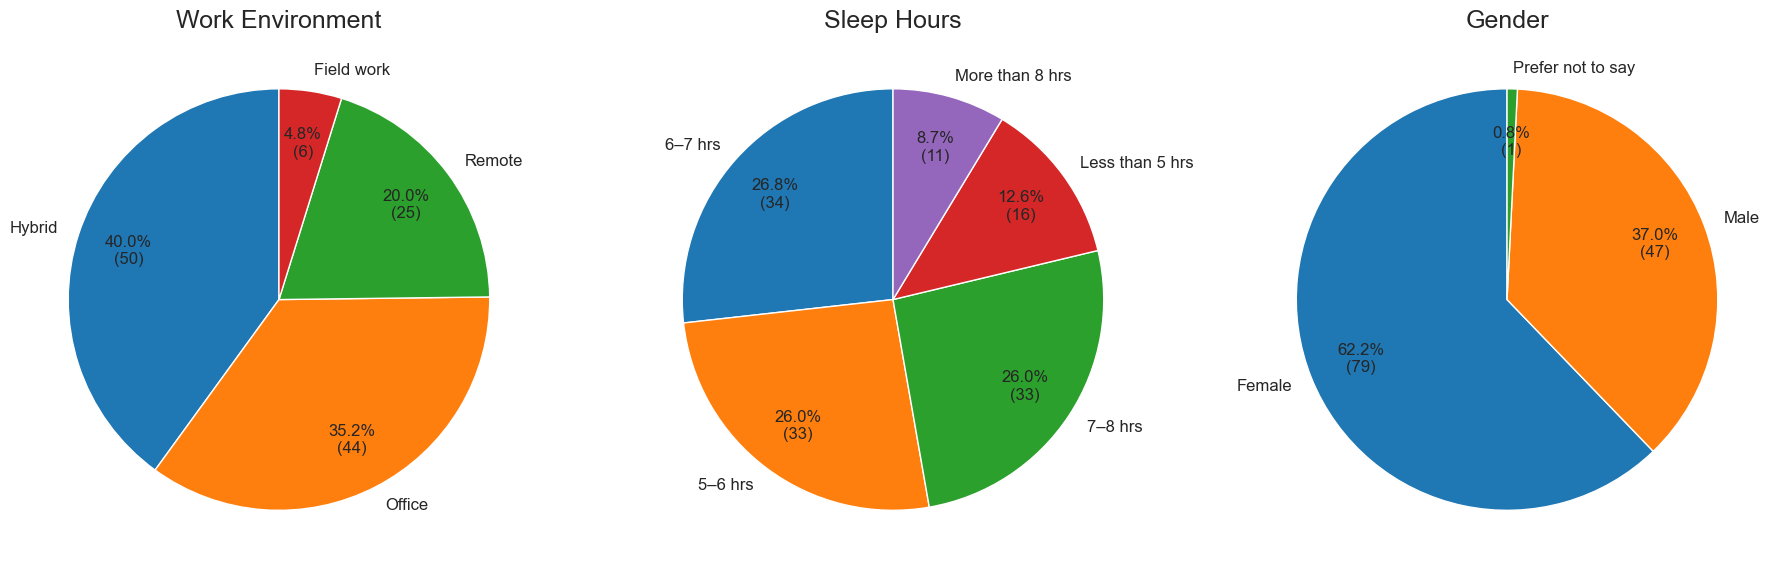

In [27]:
# Style
sns.set_style("whitegrid")

# Data
gender_counts = df['gender'].value_counts()
sleep_counts = df['sleep_hours'].value_counts()
work_counts = df['primary_work_environment'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Function for percentages
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return my_format

# Common text settings
label_font = {'fontsize': 14}
pct_font = {'fontsize': 12}

# Work environment
axes[0].pie(
    work_counts,
    labels=work_counts.index,
    autopct=autopct_format(work_counts),
    startangle=90,
    pctdistance=0.75,
    textprops=pct_font
)
axes[0].set_title("Work Environment", fontsize=18)

# Sleep hours
axes[1].pie(
    sleep_counts,
    labels=sleep_counts.index,
    autopct=autopct_format(sleep_counts),
    startangle=90,
    pctdistance=0.75,
    textprops=pct_font
)
axes[1].set_title("Sleep Hours", fontsize=18)

# Gender
axes[2].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct=autopct_format(gender_counts),
    startangle=90,
    pctdistance=0.75,
    textprops=pct_font
)
axes[2].set_title("Gender", fontsize=18)

plt.tight_layout()
plt.show()

C:\Users\Access\AppData\Local\Temp\ipykernel_4728\469006764.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


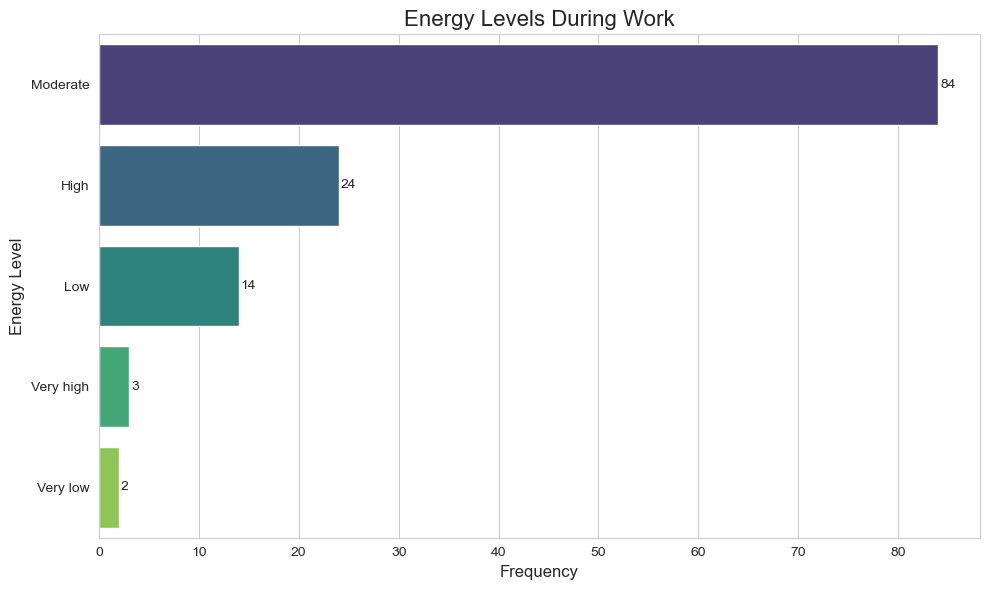

In [28]:
# Data
counts = df['energy_levels_per_workday'].value_counts()

# Style
sns.set_style("whitegrid")

# Figure
plt.figure(figsize=(10, 6))

# Seaborn barplot (horizontal)
sns.barplot(
    x=counts.values,
    y=counts.index,
    palette="viridis"
)

# Titles
plt.title("Energy Levels During Work", fontsize=16)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Energy Level", fontsize=12)

# Add values on bars
for i, v in enumerate(counts.values):
    plt.text(v + 0.2, i, str(v), va='center')

plt.tight_layout()
plt.show()


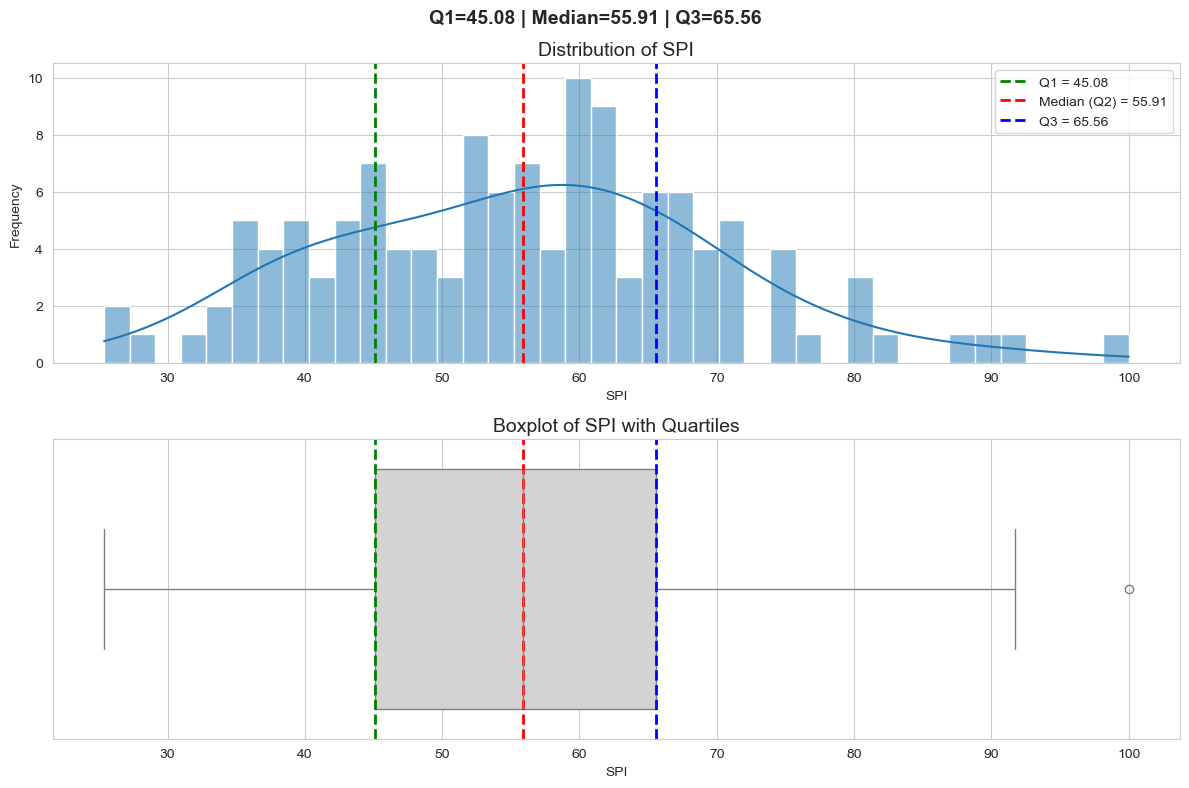

In [29]:
data = df['Overall_sleep_Productivity_Impact_index(SPI)']

# Quartiles
q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)
q3 = np.percentile(data, 75)

sns.set_style("whitegrid")

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Histogram + KDE
sns.histplot(data, bins=40, kde=True, ax=ax[0])

# Colored quartile lines
ax[0].axvline(q1, linestyle='--', linewidth=2, color='green', label=f'Q1 = {q1:.2f}')
ax[0].axvline(q2, linestyle='--', linewidth=2, color='red', label=f'Median (Q2) = {q2:.2f}')
ax[0].axvline(q3, linestyle='--', linewidth=2, color='blue', label=f'Q3 = {q3:.2f}')

ax[0].set_title('Distribution of SPI', fontsize=14)
ax[0].set_xlabel('SPI')
ax[0].set_ylabel('Frequency')
ax[0].legend()

# Boxplot
sns.boxplot(x=data, ax=ax[1], color="lightgray")

# Same quartile lines on boxplot
ax[1].axvline(q1, linestyle='--', linewidth=2, color='green')
ax[1].axvline(q2, linestyle='--', linewidth=2, color='red')
ax[1].axvline(q3, linestyle='--', linewidth=2, color='blue')

ax[1].set_title('Boxplot of SPI with Quartiles', fontsize=14)
ax[1].set_xlabel('SPI')

# Show values clearly on figure
fig.suptitle(
    f"Q1={q1:.2f} | Median={q2:.2f} | Q3={q3:.2f}",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()